## Memos

If you ran the `fibonacci` function from [Chapter 6](section_fibonacci), maybe you noticed that the bigger the argument you provide, the longer the function takes to run.

In [45]:
def fibonacci(n):
    if n == 0:
        return 0

    if n == 1:
        return 1

    return fibonacci(n-1) + fibonacci(n-2)

Furthermore, the run time increases quickly.
To understand why, consider the following figure, which shows the **call graph** for
`fibonacci` with `n=4`:

In [46]:
from diagram import make_binding, Frame, Arrow

bindings = [make_binding('n', i) for i in range(5)]
frames = [Frame([binding]) for binding in bindings]

In [47]:
arrowprops = dict(arrowstyle="-", color='gray', alpha=0.5, ls='-', lw=0.5)

def left_arrow(ax, bbox1, bbox2):
    x = bbox1.xmin + 0.1
    y = bbox1.ymin
    dx = bbox2.xmax - x - 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

def right_arrow(ax, bbox1, bbox2):
    x = bbox1.xmax - 0.1
    y = bbox1.ymin
    dx = bbox2.xmin - x + 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

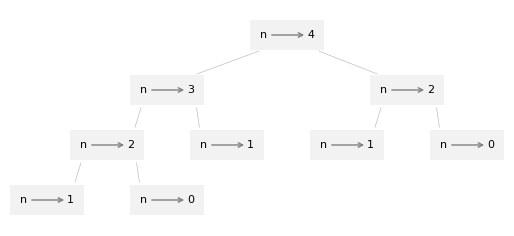

In [48]:
from diagram import diagram, adjust, Bbox

width, height, x, y = [4.94, 2.16, -1.03, 1.91]
ax = diagram(width, height)

dx = 0.6
dy = 0.55

bboxes = []
bboxes.append(frames[4].draw(ax, x+6*dx, y))

bboxes.append(frames[3].draw(ax, x+4*dx, y-dy))
bboxes.append(frames[2].draw(ax, x+8*dx, y-dy))

bboxes.append(frames[2].draw(ax, x+3*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+5*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+7*dx, y-2*dy))
bboxes.append(frames[0].draw(ax, x+9*dx, y-2*dy))

bboxes.append(frames[1].draw(ax, x+2*dx, y-3*dy))
bboxes.append(frames[0].draw(ax, x+4*dx, y-3*dy))

left_arrow(ax, bboxes[0], bboxes[1])
left_arrow(ax, bboxes[1], bboxes[3])
left_arrow(ax, bboxes[3], bboxes[7])
left_arrow(ax, bboxes[2], bboxes[5])

right_arrow(ax, bboxes[0], bboxes[2])
right_arrow(ax, bboxes[1], bboxes[4])
right_arrow(ax, bboxes[2], bboxes[6])
right_arrow(ax, bboxes[3], bboxes[8])

bbox = Bbox.union(bboxes)
# adjust(x, y, bbox)

A call graph shows a set of function frames, with lines connecting each frame to the frames of the functions it calls.
At the top of the graph, `fibonacci` with `n=4` calls `fibonacci` with ` n=3` and `n=2`.
In turn, `fibonacci` with `n=3` calls `fibonacci` with `n=2` and `n=1`. And so on.

Count how many times `fibonacci(0)` and `fibonacci(1)` are called.
This is an inefficient solution to the problem, and it gets worse as the argument gets bigger.

One solution is to keep track of values that have already been computed by storing them in a dictionary.
A previously computed value that is stored for later use is called a **memo**.
Here is a "memoized" version of `fibonacci`:

In [48]:
known = {0:0, 1:1}

def fibonacci_memo(n):
    if n in known:
        return known[n]

    res = fibonacci_memo(n-1) + fibonacci_memo(n-2)
    known[n] = res
    return res

`known` is a dictionary that keeps track of the Fibonacci numbers we already know
It starts with two items: `0` maps to `0` and `1` maps to `1`.

Whenever `fibonacci_memo` is called, it checks `known`.
If the result is already there, it can return immediately.
Otherwise it has to compute the new value, add it to the dictionary, and return it.

Comparing the two functions, `fibonacci(40)` takes about 30 seconds to run.
`fibonacci_memo(40)` takes about 30 microseconds, so it's a million times faster.
In the notebook for this chapter, you'll see where these measurements come from.

In [49]:
# %time fibonacci(40)

In [51]:
%time fibonacci_memo(40)

CPU times: total: 0 ns
Wall time: 0 ns


102334155

## Debugging

As you work with bigger datasets it can become unwieldy to debug by printing and checking the output by hand. Here are some suggestions for debugging large datasets:

1.  Scale down the input: If possible, reduce the size of the dataset. For example if the
    program reads a text file, start with just the first 10 lines, or
    with the smallest example you can find. You can either edit the
    files themselves, or (better) modify the program so it reads only
    the first `n` lines.

    If there is an error, you can reduce `n` to the smallest value where the error occurs.
    As you find and correct errors, you can increase `n` gradually.

2. Check summaries and types: Instead of printing and checking the entire dataset, consider
    printing summaries of the data -- for example, the number of items in
    a dictionary or the total of a list of numbers.

    A common cause of runtime errors is a value that is not the right type. For debugging this kind of error, it is often enough to print the type of a value.

3. Write self-checks: Sometimes you can write code to check for errors automatically. For
    example, if you are computing the average of a list of numbers, you
    could check that the result is not greater than the largest element
    in the list or less than the smallest. This is called a "sanity
    check" because it detects results that are "insane".

    Another kind of check compares the results of two different computations to see if they are consistent. This is called a "consistency check".

4. Format the output: Formatting debugging output can make it easier to spot an error. We saw an example in [Chapter 6](section_debugging_factorial). Another tool you might find useful is the `pprint` module, which provides a `pprint` function that displays built-in types in a more human-readable format (`pprint` stands for "pretty print").

    Again, time you spend building scaffolding can reduce the time you spend debugging.

## Glossary

**dictionary:**
 An object that contains key-value pairs, also called items.

**item:**
 In a dictionary, another name for a key-value pair.

**key:**
 An object that appears in a dictionary as the first part of a key-value pair.

**value:**
 An object that appears in a dictionary as the second part of a key-value pair. This is more specific than our previous use of the word "value".

**mapping:**
  A relationship in which each element of one set corresponds to an element of another set.

**hash table:**
A collection of key-value pairs organized so that we can look up a key and find its value efficiently.

**hashable:**
 Immutable types like integers, floats and strings are hashable.
 Mutable types like lists and dictionaries are not.

**hash function:**
A function that takes an object and computes an integer that is used to locate a key in a hash table.

**accumulator:**
 A variable used in a loop to add up or accumulate a result.

**filtering:**
Looping through a sequence and selecting or omitting elements.

**call graph:**
A diagram that shows every frame created during the execution of a program, with an arrow from each caller to each callee.

**memo:**
 A computed value stored to avoid unnecessary future computation.

## Exercises

In [52]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Ask a virtual assistant

In this chapter, I said the keys in a dictionary have to be hashable and I gave a short explanation. If you would like more details, ask a virtual assistant, "Why do keys in Python dictionaries have to be hashable?"

In [a previous section](section_dictionary_in_operator), we stored a list of words as keys in a dictionary so that we could use an efficient version of the `in` operator.
We could have done the same thing using a `set`, which is another built-in data type.
Ask a virtual assistant, "How do I make a Python set from a list of strings and check whether a string is an element of the set?"

### Exercise

Dictionaries have a method called `get` that takes a key and a default value.
If the key appears in the dictionary, `get` returns the corresponding value; otherwise it returns the default value.
For example, here's a dictionary that maps from the letters in a string to the number of times they appear.

In [ ]:
counter = value_counts('brontosaurus')

If we look up a letter that appears in the word, `get` returns the number of times it appears.

In [54]:
counter.get('b', 0)

1

If we look up a letter that doesn't appear, we get the default value, `0`.

In [55]:
counter.get('c', 0)

0

Use `get` to write a more concise version of `value_counts`.
You should be able to eliminate the `if` statement.

### Exercise

What is the longest word you can think of where each letter appears only once?
Let's see if we can find one longer than `unpredictably`.

Write a function named `has_duplicates` that takes a sequence -- like a list or string -- as a parameter and returns `True` if there is any element that appears in the sequence more than once.

To get you started, here's an outline of the function with doctests.

In [ ]:
def has_duplicates(t):
    """Check whether any element in a sequence appears more than once.

    >>> has_duplicates('banana')
    True
    >>> has_duplicates('ambidextrously')
    False
    >>> has_duplicates([1, 2, 2])
    True
    >>> has_duplicates([1, 2, 3])
    False
    """
    return None

In [ ]:
# Solution goes here

You can use `doctest` to test your function.

In [58]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

run_doctests(has_duplicates)

**********************************************************************
File "__main__", line 4, in has_duplicates
Failed example:
    has_duplicates('banana')
Expected:
    True
Got nothing
**********************************************************************
File "__main__", line 6, in has_duplicates
Failed example:
    has_duplicates('ambidextrously')
Expected:
    False
Got nothing
**********************************************************************
File "__main__", line 8, in has_duplicates
Failed example:
    has_duplicates([1, 2, 2])
Expected:
    True
Got nothing
**********************************************************************
File "__main__", line 10, in has_duplicates
Failed example:
    has_duplicates([1, 2, 3])
Expected:
    False
Got nothing


You can use this loop to find the longest words with no repeated letters.

In [59]:
no_repeats = []

for word in word_list:
    if len(word) > 12 and not has_duplicates(word):
        no_repeats.append(word)

no_repeats

['abbreviations',
 'abnormalities',
 'abrasivenesses',
 'absentmindedly',
 'absentmindedness',
 'absentmindednesses',
 'abstractnesses',
 'abstrusenesses',
 'abusivenesses',
 'accelerations',
 'accentuations',
 'acceptabilities',
 'acceptability',
 'accessibilities',
 'accessibility',
 'acclimatization',
 'acclimatizations',
 'accommodating',
 'accommodation',
 'accommodations',
 'accompaniment',
 'accompaniments',
 'accomplishers',
 'accomplishing',
 'accomplishment',
 'accomplishments',
 'accountabilities',
 'accountability',
 'accountancies',
 'accoutrements',
 'accumulations',
 'accuratenesses',
 'acknowledgement',
 'acknowledgements',
 'acknowledging',
 'acknowledgment',
 'acknowledgments',
 'acquaintances',
 'acquaintanceship',
 'acquaintanceships',
 'acquiescences',
 'acquiescently',
 'actualization',
 'actualizations',
 'acupuncturist',
 'acupuncturists',
 'adaptabilities',
 'adjudications',
 'administrable',
 'administrants',
 'administration',
 'administrations',
 'administra

### Exercise

Write a function called `find_repeats` that takes a dictionary that maps from each key to a counter, like the result from `value_counts`.
It should loop through the dictionary and return a list of keys that have counts greater than `1`.
You can use the following outline to get started.

In [ ]:
def find_repeats(counter):
    """Makes a list of keys with values greater than 1.

    counter: dictionary that maps from keys to counts

    returns: list of keys
    """
    return []

In [60]:
# Solution goes here

You can use the following examples to test your code.
First, we'll make a dictionary that maps from letters to counts.

In [ ]:
counter1 = value_counts('banana')
counter1

{'b': 1, 'a': 3, 'n': 2}

The result from `find_repeats` should be `['a', 'n']`.

In [ ]:
repeats = find_repeats(counter1)
repeats

[]

Here's another example that starts with a list of numbers.
The result should be `[1, 2]`.

In [ ]:
counter1 = value_counts([1, 2, 3, 2, 1])
repeats = find_repeats(counter1)
repeats

[]

### Exercise

Suppose you run `value_counts` with two different words and save the results in two dictionaries.

In [ ]:
counter1 = value_counts('brontosaurus')
counter2 = value_counts('apatosaurus')

Each dictionary maps from a set of letters to the number of times they appear.
Write a function called `add_counters` that takes two dictionaries like this and returns a new dictionary that contains all of the letters and the total number of times they appear in either word.

There are many ways to solve this problem.
Once you have a working solution, consider asking a virtual assistant for different solutions.

In [ ]:
# Solution goes here

In [66]:
# Solution goes here

### Exercise

A word is "interlocking" if we can split it into two words by taking alternating letters.
For example, "schooled" is an interlocking word because it can be split into "shoe" and "cold".

To select alternating letters from a string, you can use a slice operator with three components that indicate where to start, where to stop, and the "step size" between the letters.

In the following slice, the first component is `0`, so we start with the first letter.
The second component is `None`, which means we should go all the way to the end of the string.
And the third component is `2`, so there are two steps between the letters we select.

In [68]:
word = 'schooled'
first = word[0:None:2]
first

'shoe'

Instead of providing `None` as the second component, we can get the same effect by leaving it out altogether.
For example, the following slice selects alternating letters, starting with the second letter.

In [69]:
second = word[1::2]
second

'cold'

Write a function called `is_interlocking` that takes a word as an argument and returns `True` if it can be split into two interlocking words.

In [70]:
# Solution goes here

You can use the following loop to find the interlocking words in the word list.

In [71]:
for word in word_list:
    if len(word) >= 8 and is_interlocking(word):
        first = word[0::2]
        second = word[1::2]
        print(word, first, second)

NameError: name 'is_interlocking' is not defined

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)